# DTW Benchmarking: CPU vs GPU

This notebook compares the CPU (tslearn + numpy) and GPU (CUDA) backends for DTW computation.

**What we benchmark:**
1. Correctness — do CPU and GPU produce the same results?
2. `dtw_distance` — single-pair timing across sequence lengths
3. `dtw_pairwise` — batch timing across number of sequences
4. Open boundary conditions (`open_start`, `open_end`)

**Note:** On a CPU-only machine, GPU benchmarks are skipped and only CPU results are shown.

In [1]:
import time
import numpy as np
import pandas as pd
from baleen._cuda_dtw import dtw_distance, dtw_pairwise, backend, CUDA_AVAILABLE

print(f"Backend: {backend()}")
print(f"CUDA available: {CUDA_AVAILABLE}")

🚀 DTW: GPU (CUDA) acceleration ENABLED
Backend: cuda
CUDA available: True


## 1. Correctness Verification

If GPU is available, verify that CPU and GPU produce identical results (within floating-point tolerance).

In [2]:
rng = np.random.default_rng(42)

if CUDA_AVAILABLE:
    print("=== Correctness: dtw_distance ===")
    for length in [10, 50, 100, 500]:
        seq1 = rng.standard_normal(length).astype(np.float32)
        seq2 = rng.standard_normal(length).astype(np.float32)
        d_cpu = dtw_distance(seq1, seq2, use_cuda=False)
        d_gpu = dtw_distance(seq1, seq2, use_cuda=True)
        diff = abs(d_cpu - d_gpu)
        status = "✅" if diff < 1e-4 else "❌"
        print(f"  len={length:>4d}  CPU={d_cpu:.6f}  GPU={d_gpu:.6f}  diff={diff:.2e}  {status}")

    print("\n=== Correctness: dtw_distance (open_end=True) ===")
    for length in [10, 50, 100, 500]:
        seq1 = rng.standard_normal(length).astype(np.float32)
        seq2 = rng.standard_normal(length + length // 2).astype(np.float32)
        d_cpu = dtw_distance(seq1, seq2, use_open_end=True, use_cuda=False)
        d_gpu = dtw_distance(seq1, seq2, use_open_end=True, use_cuda=True)
        diff = abs(d_cpu - d_gpu)
        status = "✅" if diff < 1e-4 else "❌"
        print(f"  len={length:>4d}  CPU={d_cpu:.6f}  GPU={d_gpu:.6f}  diff={diff:.2e}  {status}")

    print("\n=== Correctness: dtw_distance (open_start=True) ===")
    for length in [10, 50, 100, 500]:
        seq1 = rng.standard_normal(length).astype(np.float32)
        seq2 = rng.standard_normal(length + length // 2).astype(np.float32)
        d_cpu = dtw_distance(seq1, seq2, use_open_start=True, use_cuda=False)
        d_gpu = dtw_distance(seq1, seq2, use_open_start=True, use_cuda=True)
        diff = abs(d_cpu - d_gpu)
        status = "✅" if diff < 1e-4 else "❌"
        print(f"  len={length:>4d}  CPU={d_cpu:.6f}  GPU={d_gpu:.6f}  diff={diff:.2e}  {status}")

    print("\n=== Correctness: dtw_pairwise ===")
    for n_seq in [5, 20, 50]:
        seqs = rng.standard_normal((n_seq, 100)).astype(np.float32)
        m_cpu = dtw_pairwise(seqs, use_cuda=False)
        m_gpu = dtw_pairwise(seqs, use_cuda=True)
        max_diff = np.max(np.abs(m_cpu - m_gpu))
        status = "✅" if max_diff < 1e-3 else "❌"
        print(f"  n={n_seq:>3d}  max_diff={max_diff:.2e}  {status}")
else:
    print("GPU not available — skipping correctness comparison.")
    print("CPU-only results will be shown in the benchmarks below.")

=== Correctness: dtw_distance ===
  len=  10  CPU=2.049890  GPU=2.049890  diff=2.62e-08  ✅
  len=  50  CPU=4.005620  GPU=4.005620  diff=2.67e-07  ✅
  len= 100  CPU=6.649175  GPU=6.649175  diff=3.48e-07  ✅
  len= 500  CPU=15.245757  GPU=15.245756  diff=6.63e-07  ✅

=== Correctness: dtw_distance (open_end=True) ===
  len=  10  CPU=0.262649  GPU=0.264715  diff=2.07e-03  ❌
  len=  50  CPU=0.101715  GPU=0.106372  diff=4.66e-03  ❌
  len= 100  CPU=0.068682  GPU=0.069501  diff=8.19e-04  ❌
  len= 500  CPU=0.029172  GPU=0.029249  diff=7.74e-05  ✅

=== Correctness: dtw_distance (open_start=True) ===
  len=  10  CPU=0.300817  GPU=0.300817  diff=3.46e-09  ✅
  len=  50  CPU=0.094892  GPU=0.094892  diff=8.09e-09  ✅
  len= 100  CPU=0.062377  GPU=0.062377  diff=2.02e-10  ✅
  len= 500  CPU=0.028574  GPU=0.028574  diff=1.04e-09  ✅

=== Correctness: dtw_pairwise ===
  n=  5  max_diff=9.87e-07  ✅
  n= 20  max_diff=1.96e-06  ✅
  n= 50  max_diff=2.13e-06  ✅



[Complete] Computed 10 pairs in 0.00 seconds (inf pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 77000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (63333.3 pairs/sec)
[Progress] Ref seq  11/49 | Completed:    484/1225 pairs (39.5%) | Speed: 242000.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  21/49 | Completed:    819/1225 pairs (66.9%) | Speed: 273000.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  31/49 | Completed:   1054/1225 pairs (86.0%) | Speed: 210800.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  41/49 | Completed:   1189/1225 pairs (97.1%) | Speed: 169857.1 pairs/sec | ETA: 0.0 sec

[Complete] Computed 1225 pairs in 0.01 seconds (153125.0 pairs/sec)


## 2. Single-pair `dtw_distance` Benchmark

Measure time for a single `dtw_distance` call across increasing sequence lengths.

In [3]:
def bench_dtw_distance(seq_lengths, n_repeats=5):
    """Benchmark dtw_distance across sequence lengths."""
    rng = np.random.default_rng(123)
    rows = []

    for length in seq_lengths:
        seq1 = rng.standard_normal(length).astype(np.float32)
        seq2 = rng.standard_normal(length).astype(np.float32)

        # CPU (tslearn)
        times_cpu = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            dtw_distance(seq1, seq2, use_cuda=False)
            times_cpu.append(time.perf_counter() - t0)
        cpu_ms = np.median(times_cpu) * 1000

        row = {"seq_length": length, "cpu_ms": cpu_ms}

        # GPU
        if CUDA_AVAILABLE:
            # warmup
            dtw_distance(seq1, seq2, use_cuda=True)
            times_gpu = []
            for _ in range(n_repeats):
                t0 = time.perf_counter()
                dtw_distance(seq1, seq2, use_cuda=True)
                times_gpu.append(time.perf_counter() - t0)
            gpu_ms = np.median(times_gpu) * 1000
            row["gpu_ms"] = gpu_ms
            row["speedup"] = cpu_ms / gpu_ms if gpu_ms > 0 else float("inf")

        rows.append(row)

    return pd.DataFrame(rows)


seq_lengths = [50, 100, 200, 500, 1000, 2000, 5000]
df_single = bench_dtw_distance(seq_lengths)
print("=== dtw_distance benchmark (median, ms) ===")
print(df_single.to_string(index=False, float_format="%.3f"))

=== dtw_distance benchmark (median, ms) ===
 seq_length  cpu_ms  gpu_ms  speedup
         50   0.711   1.547    0.459
        100   0.802   1.365    0.588
        200   1.604   1.632    0.983
        500   4.439   2.075    2.139
       1000  11.607   3.116    3.725
       2000  20.824   8.049    2.587
       5000 251.738  42.801    5.882


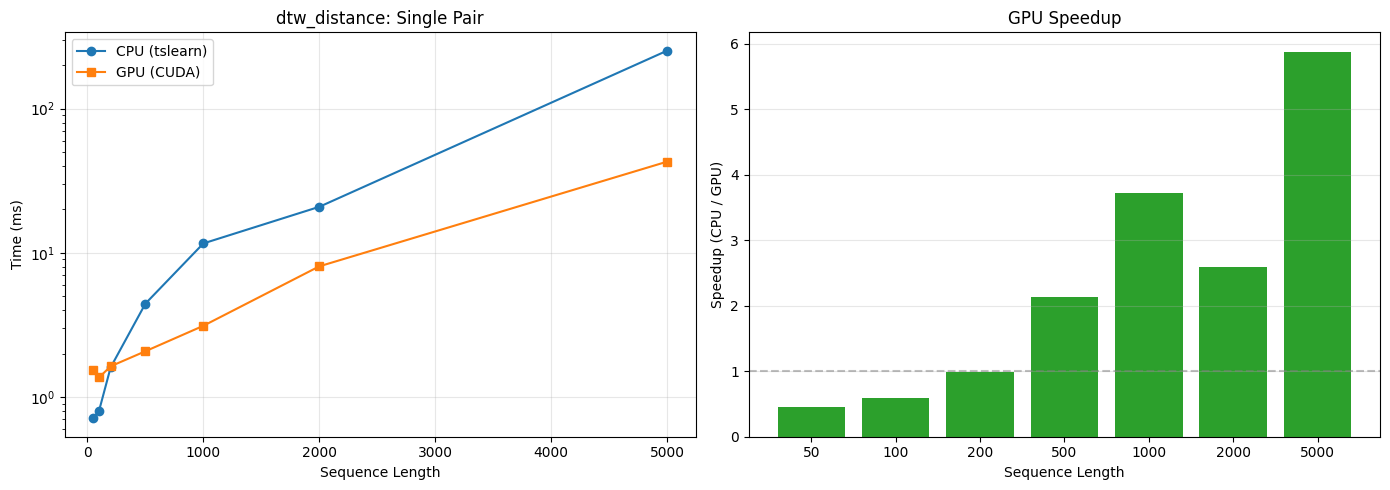

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute time
ax = axes[0]
ax.plot(df_single["seq_length"], df_single["cpu_ms"], "o-", label="CPU (tslearn)", color="tab:blue")
if "gpu_ms" in df_single.columns:
    ax.plot(df_single["seq_length"], df_single["gpu_ms"], "s-", label="GPU (CUDA)", color="tab:orange")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Time (ms)")
ax.set_title("dtw_distance: Single Pair")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: speedup
ax = axes[1]
if "speedup" in df_single.columns:
    ax.bar(df_single["seq_length"].astype(str), df_single["speedup"], color="tab:green")
    ax.set_xlabel("Sequence Length")
    ax.set_ylabel("Speedup (CPU / GPU)")
    ax.set_title("GPU Speedup")
    ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
    ax.grid(True, alpha=0.3, axis="y")
else:
    ax.text(0.5, 0.5, "GPU not available", ha="center", va="center", transform=ax.transAxes, fontsize=14)
    ax.set_title("GPU Speedup (N/A)")

plt.tight_layout()
plt.show()

## 3. Pairwise `dtw_pairwise` Benchmark

Measure time for computing the full pairwise distance matrix across increasing batch sizes (fixed sequence length = 100).

In [5]:
def bench_dtw_pairwise(n_seqs_list, seq_length=100, n_repeats=3):
    """Benchmark dtw_pairwise across batch sizes."""
    rng = np.random.default_rng(456)
    rows = []

    for n_seq in n_seqs_list:
        seqs = rng.standard_normal((n_seq, seq_length)).astype(np.float32)
        n_pairs = n_seq * (n_seq - 1) // 2

        # CPU
        times_cpu = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            dtw_pairwise(seqs, use_cuda=False)
            times_cpu.append(time.perf_counter() - t0)
        cpu_s = np.median(times_cpu)
        cpu_pairs_sec = n_pairs / cpu_s if cpu_s > 0 else 0

        row = {
            "n_sequences": n_seq,
            "n_pairs": n_pairs,
            "cpu_sec": cpu_s,
            "cpu_pairs/sec": cpu_pairs_sec,
        }

        # GPU
        if CUDA_AVAILABLE:
            # warmup
            dtw_pairwise(seqs, use_cuda=True)
            times_gpu = []
            for _ in range(n_repeats):
                t0 = time.perf_counter()
                dtw_pairwise(seqs, use_cuda=True)
                times_gpu.append(time.perf_counter() - t0)
            gpu_s = np.median(times_gpu)
            gpu_pairs_sec = n_pairs / gpu_s if gpu_s > 0 else 0
            row["gpu_sec"] = gpu_s
            row["gpu_pairs/sec"] = gpu_pairs_sec
            row["speedup"] = cpu_s / gpu_s if gpu_s > 0 else float("inf")

        rows.append(row)
        print(f"  n_seq={n_seq:>4d}  pairs={n_pairs:>7d}  done")

    return pd.DataFrame(rows)


# Adjust sizes based on whether GPU is available
# CPU-only: keep small to avoid long waits
if CUDA_AVAILABLE:
    n_seqs_list = [10, 20, 50, 100, 200, 500, 1000]
else:
    n_seqs_list = [10, 20, 50, 100, 200]

print(f"Benchmarking pairwise DTW (seq_length=100)...")
df_pairwise = bench_dtw_pairwise(n_seqs_list)
print("\n=== dtw_pairwise benchmark ===")
print(df_pairwise.to_string(index=False, float_format="%.4f"))

Benchmarking pairwise DTW (seq_length=100)...
  n_seq=  10  pairs=     45  done
  n_seq=  20  pairs=    190  done



[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)

[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)

[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)

[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (63333.3 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (63333.3 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (63333.3 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (63333.3 pairs/sec)
[Progress] Ref seq  11/49 | Completed:  

  n_seq=  50  pairs=   1225  done


[Progress] Ref seq  11/99 | Completed:   1034/4950 pairs (20.9%) | Speed: 344666.7 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  21/99 | Completed:   1869/4950 pairs (37.8%) | Speed: 311500.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  31/99 | Completed:   2604/4950 pairs (52.6%) | Speed: 325500.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  41/99 | Completed:   3239/4950 pairs (65.4%) | Speed: 323900.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  51/99 | Completed:   3774/4950 pairs (76.2%) | Speed: 314500.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  61/99 | Completed:   4209/4950 pairs (85.0%) | Speed: 300642.8 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  71/99 | Completed:   4544/4950 pairs (91.8%) | Speed: 302933.3 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  81/99 | Completed:   4779/4950 pairs (96.5%) | Speed: 281117.7 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  91/99 | Completed:   4914/4950 pairs (99.3%) | Speed: 258631.6 pairs/sec | ETA: 0.0 sec

[Complete] Computed 4950 pa

  n_seq= 100  pairs=   4950  done


...

  n_seq= 500  pairs= 124750  done


ess] Ref seq 371/499 | Completed: 116494/124750 pairs (93.4%) | Speed: 439600.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 381/499 | Completed: 117729/124750 pairs (94.4%) | Speed: 439287.3 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 391/499 | Completed: 118864/124750 pairs (95.3%) | Speed: 438612.5 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 401/499 | Completed: 119899/124750 pairs (96.1%) | Speed: 437587.6 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 411/499 | Completed: 120834/124750 pairs (96.9%) | Speed: 436223.8 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 421/499 | Completed: 121669/124750 pairs (97.5%) | Speed: 434532.2 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 431/499 | Completed: 122404/124750 pairs (98.1%) | Speed: 434056.8 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 441/499 | Completed: 123039/124750 pairs (98.6%) | Speed: 434766.8 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq 451/499 | Completed: 123574/124750 pairs (99.1%) | Speed: 433593.0 pairs/sec | ETA: 0.0 sec
[Progre

  n_seq=1000  pairs= 499500  done

=== dtw_pairwise benchmark ===
 n_sequences  n_pairs  cpu_sec  cpu_pairs/sec  gpu_sec  gpu_pairs/sec  speedup
          10       45   0.0099      4532.7807   0.0029     15411.9721   3.4001
          20      190   0.0124     15317.3814   0.0045     41912.2607   2.7363
          50     1225   0.0761     16104.4620   0.0094    129835.7195   8.0621
         100     4950   0.3026     16356.0991   0.0227    218271.6126  13.3450
         200    19900   1.1997     16587.2376   0.0640    310969.6142  18.7475
         500   124750   7.4661     16708.8736   0.2787    447591.1697  26.7876
        1000   499500  29.6940     16821.5853   1.0230    488276.6919  29.0268


ss] Ref seq 191/999 | Completed: 172664/499500 pairs (34.6%) | Speed: 471759.6 pairs/sec | ETA: 0.7 sec
[Progress] Ref seq 201/999 | Completed: 180699/499500 pairs (36.2%) | Speed: 473034.0 pairs/sec | ETA: 0.7 sec
[Progress] Ref seq 211/999 | Completed: 188634/499500 pairs (37.8%) | Speed: 475148.6 pairs/sec | ETA: 0.7 sec
[Progress] Ref seq 221/999 | Completed: 196469/499500 pairs (39.3%) | Speed: 476866.5 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 231/999 | Completed: 204204/499500 pairs (40.9%) | Speed: 477112.2 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 241/999 | Completed: 211839/499500 pairs (42.4%) | Speed: 478191.9 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 251/999 | Completed: 219374/499500 pairs (43.9%) | Speed: 477939.0 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 261/999 | Completed: 226809/499500 pairs (45.4%) | Speed: 478500.0 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 271/999 | Completed: 234144/499500 pairs (46.9%) | Speed: 479803.3 pairs/sec | ETA: 0.6 sec
[Progres

ess] Ref seq 161/999 | Completed: 147959/499500 pairs (29.6%) | Speed: 511968.8 pairs/sec | ETA: 0.7 sec
[Progress] Ref seq 171/999 | Completed: 156294/499500 pairs (31.3%) | Speed: 510764.7 pairs/sec | ETA: 0.7 sec
[Progress] Ref seq 181/999 | Completed: 164529/499500 pairs (32.9%) | Speed: 509377.7 pairs/sec | ETA: 0.7 sec
[Progress] Ref seq 191/999 | Completed: 172664/499500 pairs (34.6%) | Speed: 510840.2 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 201/999 | Completed: 180699/499500 pairs (36.2%) | Speed: 510449.2 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 211/999 | Completed: 188634/499500 pairs (37.8%) | Speed: 511203.2 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 221/999 | Completed: 196469/499500 pairs (39.3%) | Speed: 510309.1 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 231/999 | Completed: 204204/499500 pairs (40.9%) | Speed: 510510.0 pairs/sec | ETA: 0.6 sec
[Progress] Ref seq 241/999 | Completed: 211839/499500 pairs (42.4%) | Speed: 510455.4 pairs/sec | ETA: 0.6 sec
[Progre

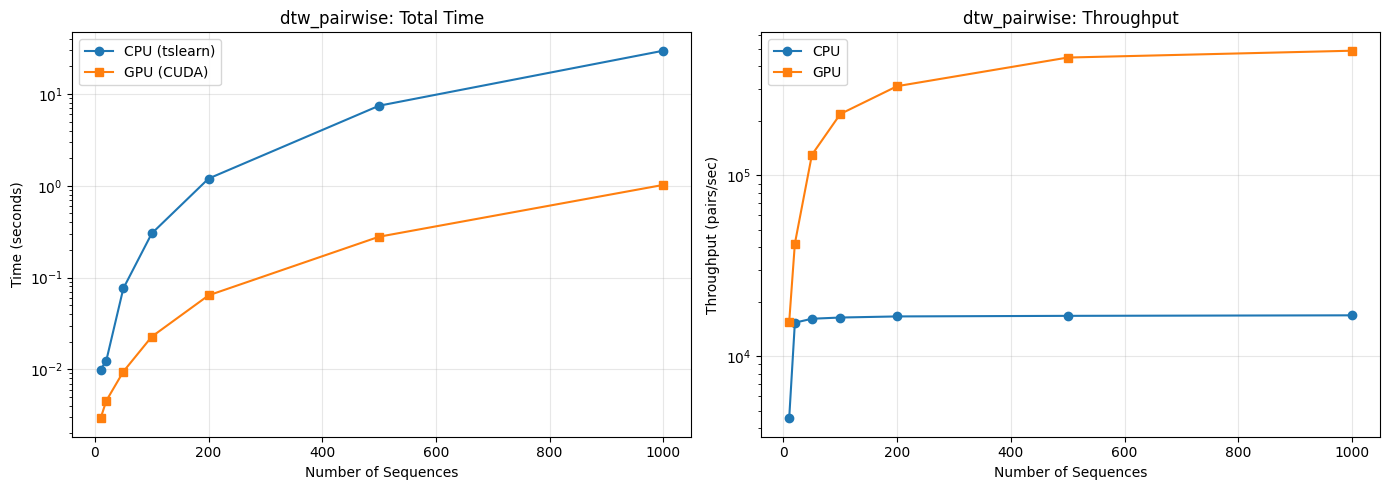

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: time vs n_sequences
ax = axes[0]
ax.plot(df_pairwise["n_sequences"], df_pairwise["cpu_sec"], "o-", label="CPU (tslearn)", color="tab:blue")
if "gpu_sec" in df_pairwise.columns:
    ax.plot(df_pairwise["n_sequences"], df_pairwise["gpu_sec"], "s-", label="GPU (CUDA)", color="tab:orange")
ax.set_xlabel("Number of Sequences")
ax.set_ylabel("Time (seconds)")
ax.set_title("dtw_pairwise: Total Time")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: throughput (pairs/sec)
ax = axes[1]
ax.plot(df_pairwise["n_sequences"], df_pairwise["cpu_pairs/sec"], "o-", label="CPU", color="tab:blue")
if "gpu_pairs/sec" in df_pairwise.columns:
    ax.plot(df_pairwise["n_sequences"], df_pairwise["gpu_pairs/sec"], "s-", label="GPU", color="tab:orange")
ax.set_xlabel("Number of Sequences")
ax.set_ylabel("Throughput (pairs/sec)")
ax.set_title("dtw_pairwise: Throughput")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Open Boundary Benchmark

Compare standard DTW vs open-boundary DTW timing on CPU (and GPU if available).  
CPU standard DTW uses tslearn; CPU open-boundary uses the numpy DP fallback.

In [7]:
def bench_open_boundary(seq_lengths, n_repeats=5):
    """Benchmark standard vs open_end DTW."""
    rng = np.random.default_rng(789)
    rows = []

    for length in seq_lengths:
        seq1 = rng.standard_normal(length).astype(np.float32)
        seq2 = rng.standard_normal(int(length * 1.5)).astype(np.float32)

        # CPU standard
        times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            dtw_distance(seq1, seq2, use_cuda=False)
            times.append(time.perf_counter() - t0)
        cpu_std_ms = np.median(times) * 1000

        # CPU open_end
        times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            dtw_distance(seq1, seq2, use_open_end=True, use_cuda=False)
            times.append(time.perf_counter() - t0)
        cpu_open_ms = np.median(times) * 1000

        # CPU open_start
        times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            dtw_distance(seq1, seq2, use_open_start=True, use_cuda=False)
            times.append(time.perf_counter() - t0)
        cpu_open_start_ms = np.median(times) * 1000

        row = {
            "seq_length": length,
            "cpu_standard_ms": cpu_std_ms,
            "cpu_open_end_ms": cpu_open_ms,
            "cpu_open_start_ms": cpu_open_start_ms,
            "open_end_overhead": cpu_open_ms / cpu_std_ms if cpu_std_ms > 0 else 0,
        }

        if CUDA_AVAILABLE:
            # GPU warmup
            dtw_distance(seq1, seq2, use_cuda=True)

            # GPU standard
            times = []
            for _ in range(n_repeats):
                t0 = time.perf_counter()
                dtw_distance(seq1, seq2, use_cuda=True)
                times.append(time.perf_counter() - t0)
            row["gpu_standard_ms"] = np.median(times) * 1000

            # GPU open_end
            times = []
            for _ in range(n_repeats):
                t0 = time.perf_counter()
                dtw_distance(seq1, seq2, use_open_end=True, use_cuda=True)
                times.append(time.perf_counter() - t0)
            row["gpu_open_end_ms"] = np.median(times) * 1000

            # GPU open_start
            times = []
            for _ in range(n_repeats):
                t0 = time.perf_counter()
                dtw_distance(seq1, seq2, use_open_start=True, use_cuda=True)
                times.append(time.perf_counter() - t0)
            row["gpu_open_start_ms"] = np.median(times) * 1000

        rows.append(row)

    return pd.DataFrame(rows)


open_lengths = [50, 100, 200, 500, 1000]
df_open = bench_open_boundary(open_lengths)
print("=== Open Boundary benchmark (median, ms) ===")
print(df_open.to_string(index=False, float_format="%.3f"))

=== Open Boundary benchmark (median, ms) ===
 seq_length  cpu_standard_ms  cpu_open_end_ms  cpu_open_start_ms  open_end_overhead  gpu_standard_ms  gpu_open_end_ms  gpu_open_start_ms
         50            0.529            4.049              4.044              7.656            1.595            1.592              1.584
        100            0.893           16.108             15.457             18.035            1.626            1.622              1.618
        200            1.635           62.968             63.758             38.511            1.720            1.724              1.719
        500            5.296          398.919            377.773             75.330            2.204            2.338              2.150
       1000           13.533         1605.301           1630.612            118.617            4.100            4.122              4.302


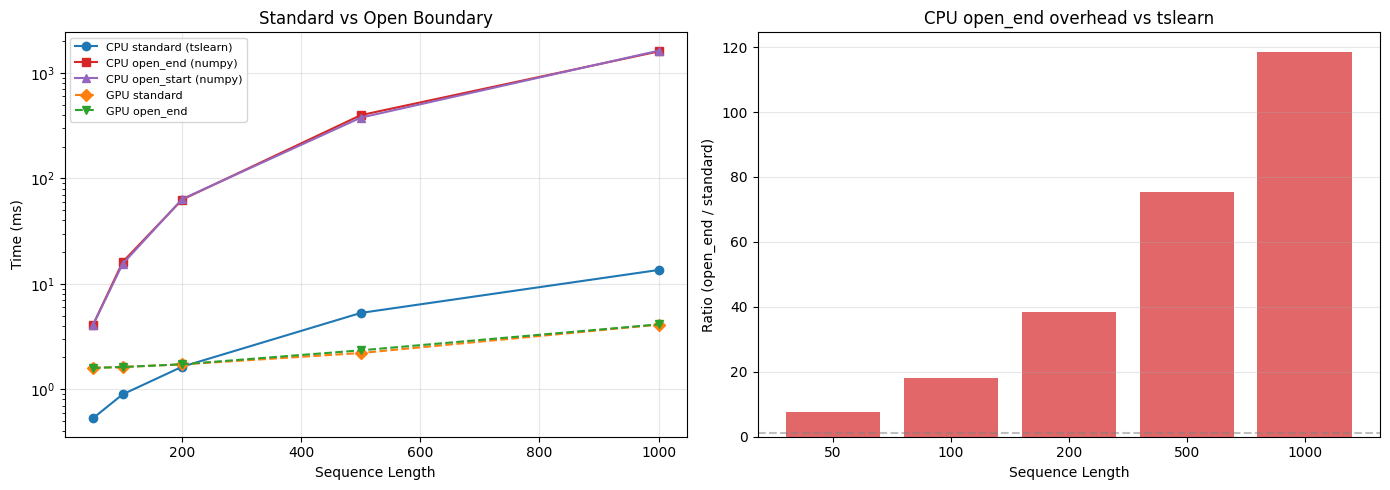

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CPU standard vs open_end vs open_start
ax = axes[0]
ax.plot(df_open["seq_length"], df_open["cpu_standard_ms"], "o-", label="CPU standard (tslearn)", color="tab:blue")
ax.plot(df_open["seq_length"], df_open["cpu_open_end_ms"], "s-", label="CPU open_end (numpy)", color="tab:red")
ax.plot(df_open["seq_length"], df_open["cpu_open_start_ms"], "^-", label="CPU open_start (numpy)", color="tab:purple")
if "gpu_standard_ms" in df_open.columns:
    ax.plot(df_open["seq_length"], df_open["gpu_standard_ms"], "D--", label="GPU standard", color="tab:orange")
    ax.plot(df_open["seq_length"], df_open["gpu_open_end_ms"], "v--", label="GPU open_end", color="tab:green")
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Time (ms)")
ax.set_title("Standard vs Open Boundary")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: overhead ratio (open_end_time / standard_time) on CPU
ax = axes[1]
ax.bar(df_open["seq_length"].astype(str), df_open["open_end_overhead"], color="tab:red", alpha=0.7)
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Ratio (open_end / standard)")
ax.set_title("CPU open_end overhead vs tslearn")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 5. Pairwise Open Boundary Benchmark

Compare pairwise standard (tslearn `cdist_dtw`) vs pairwise open_end (numpy loop) on CPU.

In [9]:
def bench_pairwise_open(n_seqs_list, seq_length=50, n_repeats=3):
    """Benchmark pairwise: standard (tslearn) vs open_end (numpy loop)."""
    rng = np.random.default_rng(321)
    rows = []

    for n_seq in n_seqs_list:
        seqs = rng.standard_normal((n_seq, seq_length)).astype(np.float32)
        n_pairs = n_seq * (n_seq - 1) // 2

        # CPU standard (tslearn cdist_dtw)
        times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            dtw_pairwise(seqs, use_cuda=False)
            times.append(time.perf_counter() - t0)
        cpu_std_s = np.median(times)

        # CPU open_end (numpy loop)
        times = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            dtw_pairwise(seqs, use_open_end=True, use_cuda=False)
            times.append(time.perf_counter() - t0)
        cpu_open_s = np.median(times)

        row = {
            "n_sequences": n_seq,
            "n_pairs": n_pairs,
            "cpu_standard_sec": cpu_std_s,
            "cpu_open_end_sec": cpu_open_s,
            "open_end_overhead": cpu_open_s / cpu_std_s if cpu_std_s > 0 else 0,
        }

        if CUDA_AVAILABLE:
            dtw_pairwise(seqs, use_cuda=True)  # warmup
            times = []
            for _ in range(n_repeats):
                t0 = time.perf_counter()
                dtw_pairwise(seqs, use_open_end=True, use_cuda=True)
                times.append(time.perf_counter() - t0)
            row["gpu_open_end_sec"] = np.median(times)

        rows.append(row)
        print(f"  n_seq={n_seq:>3d}  pairs={n_pairs:>5d}  done")

    return pd.DataFrame(rows)


# Keep small — numpy loop is O(n^2 * L^2)
pairwise_open_sizes = [5, 10, 20, 50]
print("Benchmarking pairwise open boundary (seq_length=50)...")
df_pw_open = bench_pairwise_open(pairwise_open_sizes)
print("\n=== Pairwise open boundary benchmark ===")
print(df_pw_open.to_string(index=False, float_format="%.4f"))

Benchmarking pairwise open boundary (seq_length=50)...
  n_seq=  5  pairs=   10  done



[Complete] Computed 10 pairs in 0.00 seconds (inf pairs/sec)

[Complete] Computed 10 pairs in 0.00 seconds (inf pairs/sec)

[Complete] Computed 10 pairs in 0.00 seconds (inf pairs/sec)

[Complete] Computed 10 pairs in 0.00 seconds (inf pairs/sec)

[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)


  n_seq= 10  pairs=   45  done



[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)

[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)

[Complete] Computed 45 pairs in 0.00 seconds (45000.0 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (95000.0 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (95000.0 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (95000.0 pairs/sec)
[Progress] Ref seq  11/19 | Completed:    154/190 pairs (81.1%) | Speed: 154000.0 pairs/sec | ETA: 0.0 sec

[Complete] Computed 190 pairs in 0.00 seconds (95000.0 pairs/sec)


  n_seq= 20  pairs=  190  done
  n_seq= 50  pairs= 1225  done

=== Pairwise open boundary benchmark ===
 n_sequences  n_pairs  cpu_standard_sec  cpu_open_end_sec  open_end_overhead  gpu_open_end_sec
           5       10            0.0022            0.0255            11.4662            0.0021
          10       45            0.0046            0.1172            25.6953            0.0030
          20      190            0.0121            0.5099            42.1605            0.0044
          50     1225            0.0294            3.2060           109.1162            0.0088


[Progress] Ref seq  11/49 | Completed:    484/1225 pairs (39.5%) | Speed: 484000.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  21/49 | Completed:    819/1225 pairs (66.9%) | Speed: 273000.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  31/49 | Completed:   1054/1225 pairs (86.0%) | Speed: 263500.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  41/49 | Completed:   1189/1225 pairs (97.1%) | Speed: 198166.7 pairs/sec | ETA: 0.0 sec

[Complete] Computed 1225 pairs in 0.01 seconds (175000.0 pairs/sec)
[Progress] Ref seq  11/49 | Completed:    484/1225 pairs (39.5%) | Speed: 484000.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  21/49 | Completed:    819/1225 pairs (66.9%) | Speed: 273000.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  31/49 | Completed:   1054/1225 pairs (86.0%) | Speed: 263500.0 pairs/sec | ETA: 0.0 sec
[Progress] Ref seq  41/49 | Completed:   1189/1225 pairs (97.1%) | Speed: 198166.7 pairs/sec | ETA: 0.0 sec

[Complete] Computed 1225 pairs in 0.01 seconds (175000.0 pairs/sec

## 6. Summary

In [10]:
print("=" * 60)
print("BENCHMARK SUMMARY")
print("=" * 60)
print(f"Backend: {backend()}")
print(f"CUDA available: {CUDA_AVAILABLE}")
print()

print("--- dtw_distance (single pair) ---")
print(df_single[["seq_length", "cpu_ms"] + (["gpu_ms", "speedup"] if CUDA_AVAILABLE else [])].to_string(index=False, float_format="%.3f"))
print()

print("--- dtw_pairwise (batch, seq_length=100) ---")
cols = ["n_sequences", "n_pairs", "cpu_sec"]
if CUDA_AVAILABLE:
    cols += ["gpu_sec", "speedup"]
print(df_pairwise[cols].to_string(index=False, float_format="%.4f"))
print()

print("--- Open boundary overhead (CPU: numpy DP vs tslearn) ---")
print(df_open[["seq_length", "cpu_standard_ms", "cpu_open_end_ms", "open_end_overhead"]].to_string(index=False, float_format="%.3f"))
print()

if CUDA_AVAILABLE:
    peak_speedup_single = df_single["speedup"].max()
    peak_speedup_pairwise = df_pairwise["speedup"].max()
    print(f"Peak GPU speedup (single pair): {peak_speedup_single:.1f}x")
    print(f"Peak GPU speedup (pairwise):    {peak_speedup_pairwise:.1f}x")

BENCHMARK SUMMARY
Backend: cuda
CUDA available: True

--- dtw_distance (single pair) ---
 seq_length  cpu_ms  gpu_ms  speedup
         50   0.711   1.547    0.459
        100   0.802   1.365    0.588
        200   1.604   1.632    0.983
        500   4.439   2.075    2.139
       1000  11.607   3.116    3.725
       2000  20.824   8.049    2.587
       5000 251.738  42.801    5.882

--- dtw_pairwise (batch, seq_length=100) ---
 n_sequences  n_pairs  cpu_sec  gpu_sec  speedup
          10       45   0.0099   0.0029   3.4001
          20      190   0.0124   0.0045   2.7363
          50     1225   0.0761   0.0094   8.0621
         100     4950   0.3026   0.0227  13.3450
         200    19900   1.1997   0.0640  18.7475
         500   124750   7.4661   0.2787  26.7876
        1000   499500  29.6940   1.0230  29.0268

--- Open boundary overhead (CPU: numpy DP vs tslearn) ---
 seq_length  cpu_standard_ms  cpu_open_end_ms  open_end_overhead
         50            0.529            4.049        

## 7. Pipeline Pairwise DTW: Optimized vs Original

The pipeline computes pairwise DTW for **variable-length** signals at each genomic position.
The original path goes through the full `dtw_distance()` wrapper (input conversion, validation,
contiguity checks, backend dispatch) for every single pair.

The optimized path calls `tslearn.metrics.dtw` directly with pre-shaped (N,1) arrays,
bypassing the wrapper overhead entirely.

This benchmark simulates the real pipeline scenario:
- Variable-length signals (lengths 5–100, mimicking eventalign data)
- N = 10–100 signals per position
- Standard DTW (no open boundaries)

In [ ]:
from baleen.eventalign._pipeline import (
    _compute_pairwise_batch,
    _compute_pairwise_loop,
)

def bench_pipeline_pairwise(n_signals_list, n_repeats=3):
    rng = np.random.default_rng(99)
    rows = []

    for n_sig in n_signals_list:
        signals = [
            rng.standard_normal(rng.integers(5, 100)).astype(np.float32)
            for _ in range(n_sig)
        ]
        n_pairs = n_sig * (n_sig - 1) // 2

        # Original path: through dtw_distance wrapper
        times_loop = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            m_loop = _compute_pairwise_loop(
                signals, use_cuda=False, use_open_start=False, use_open_end=False,
            )
            times_loop.append(time.perf_counter() - t0)

        # Optimized path: direct tslearn.dtw with pre-shaped arrays
        times_batch = []
        for _ in range(n_repeats):
            t0 = time.perf_counter()
            m_batch = _compute_pairwise_batch(signals)
            times_batch.append(time.perf_counter() - t0)

        max_diff = np.max(np.abs(m_loop - m_batch))
        loop_ms = np.median(times_loop) * 1000
        batch_ms = np.median(times_batch) * 1000

        rows.append({
            "n_signals": n_sig,
            "n_pairs": n_pairs,
            "original_ms": loop_ms,
            "optimized_ms": batch_ms,
            "speedup": loop_ms / batch_ms if batch_ms > 0 else float("inf"),
            "max_diff": max_diff,
        })
        print(f"  n={n_sig:>3d}  pairs={n_pairs:>5d}  "
              f"original={loop_ms:>8.1f}ms  optimized={batch_ms:>8.1f}ms  "
              f"speedup={loop_ms/batch_ms:.1f}x  max_diff={max_diff:.2e}")

    return pd.DataFrame(rows)

print("Pipeline pairwise DTW: optimized vs original")
print("(variable-length signals, lengths 5-100, standard DTW)")
print()
df_pipe = bench_pipeline_pairwise([10, 20, 40, 64, 100])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_pipe["n_signals"], df_pipe["original_ms"], "o-", label="Original (wrapper loop)", color="tab:red")
ax.plot(df_pipe["n_signals"], df_pipe["optimized_ms"], "s-", label="Optimized (direct tslearn)", color="tab:blue")
ax.set_xlabel("Number of Signals")
ax.set_ylabel("Time (ms)")
ax.set_title("Pipeline Pairwise DTW: Variable-Length Signals")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(df_pipe["n_signals"].astype(str), df_pipe["speedup"], color="tab:green")
ax.set_xlabel("Number of Signals")
ax.set_ylabel("Speedup (Original / Optimized)")
ax.set_title("Optimization Speedup")
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [11]:
from baleen._cuda_dtw import cleanup
cleanup()